### Notebook 1 — Data Understanding
**Người phụ trách:** Trần Văn Khang — 52400199 — Data & Infrastructure Lead

**Bộ dữ liệu:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

---

**Input:** `Data/Raw/online_retail_II.xlsx`

**Output:** Khám phá và ghi nhận phát hiện.

---

**Mục lục:**
1. Đọc và gộp dữ liệu.
2. Đếm số lượng giá trị duy nhất (Invoice, StockCode, Customer ID, Country).
3. Phân tích Missing Values.
4. Phân tích dòng trùng lặp (Duplicate).
5. Phân tích Invoice huỷ (Bắt đầu bằng "C").
6. Phân tích Quantity/Price âm hoặc bằng 0 — Phát hiện bút toán điều chỉnh sổ sách.
7. Phân tích StockCode không phải sản phẩm thật.
8. So sánh Outlier: IQR vs Z - Score.
9. Kiểm tra Outlier Quantity cao — Bán buôn hợp lệ hay lỗi nhập liệu?.
10. Phân tích Country.
---

### 0. Chuẩn bị môi trường

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

from scipy.stats import skew
from pathlib import Path

# Xác định thư mục gốc project để Notebook có thể import Source/
PROJECT_NOW = Path.cwd()
if (PROJECT_NOW / "Source").exists():
    PROJECT_ROOT_TAM = PROJECT_NOW
else:
    PROJECT_ROOT_TAM = PROJECT_NOW.parent
sys.path.insert(0, str(PROJECT_ROOT_TAM))


# Import các hàm dùng chung
from Source.Utils.IO import (load_raw_excel, get_project_root, RAW_DATA_DIR, INTERIM_DATA_DIR,)
from Source.Utils.Visualization import (set_plot_style, plot_histogram_boxplot, plot_missing_values, save_current_figure, 
                                        PRIMARY_COLOR, SECONDARY_COLOR, ALERT_COLOR,)

set_plot_style()
# Kiểm tra đường dẫn
print(f"Thư mục gốc dự án : {get_project_root()}")
print(f"Thư mục dữ liệu thô: {RAW_DATA_DIR}")

Thư mục gốc dự án : D:\Lilith\Customer-Analytics-for-E-Commerce
Thư mục dữ liệu thô: D:\Lilith\Customer-Analytics-for-E-Commerce\Data\Raw


### 1. Đọc và gộp dữ liệu

- Dữ liệu gốc gồm 2 sheet Excel: `Year 2009-2010` và `Year 2010-2011`. 
- Ta gộp lại thành 1 DataFrame duy nhất bằng hàm `load_raw_excel()` đã viết sẵn trong `Source/Utils/IO.py`.

**Lưu ý:** Gộp 2 Sheet thực hiện ở bước này, trước khi kiểm tra trùng lặp.

In [4]:
df = load_raw_excel()

print(f"Shape sau khi gộp 2 Sheet: {df.shape[0]:,} dòng × {df.shape[1]} cột")

print(f"\nDanh sách cột: ")
print(list(df.columns))

print("\nKiểu dữ liệu từng cột: ")
print(df.dtypes)

print("\n5 dòng đầu tiên: ")
display(df.head())

Shape sau khi gộp 2 Sheet: 1,067,371 dòng × 9 cột

Danh sách cột: 
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Sheet']

Kiểu dữ liệu từng cột: 
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
Sheet                     str
dtype: object

5 dòng đầu tiên: 


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010


In [20]:
# Khoảng thời gian dữ liệu bao phủ
print(f"Ngày giao dịch sớm nhất : {df['InvoiceDate'].min()}")
print(f"Ngày giao dịch muộn nhất: {df['InvoiceDate'].max()}")
print(f"Tổng số ngày            : {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days:,} ngày")

df.head()

Ngày giao dịch sớm nhất : 2009-12-01 07:45:00
Ngày giao dịch muộn nhất: 2011-12-09 12:50:00
Tổng số ngày            : 738 ngày


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010


**Nhận xét:** 
- Dữ liệu trải dài khoảng 2 năm (01/12/2009 – 09/12/2011).
- 9 cột dữ liệu gồm 8 cột gốc (`Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country`)
và 1 cột `Sheet` được thêm vào để truy vết dòng dữ liệu đến từ Sheet nào.

### 2. Đếm số lượng giá trị duy nhất

In [22]:
bang_cardinality = pd.DataFrame({
    "Số giá trị duy nhất": [
        df["Invoice"].nunique(),
        df["StockCode"].nunique(),
        df["Customer ID"].nunique(),
        df["Country"].nunique(),
    ]
}, index=["Invoice", "StockCode", "Customer ID", "Country"])

bang_cardinality["Tỷ lệ duy nhất (%)"] = (
    bang_cardinality["Số giá trị duy nhất"] / len(df) * 100
).round(2)

bang_cardinality

,Số giá trị duy nhất,Tỷ lệ duy nhất (%)
Invoice,53628,5.02
StockCode,5305,0.50
Customer ID,5942,0.56
Country,43,0.00


**Nhận xét:** 
- Số `Invoice` duy nhất thể hiện số mã hoá đơn khác nhau trong dữ liệu thô, bao gồm cả các hoá đơn liên quan đến giao dịch huỷ. 

- Số `Customer ID` duy nhất thể hiện số khách hàng có định danh trong dữ liệu, là quy mô khách hàng thực tế, là một thông tin đầu vào quan trọng cho các bước phân tích RFM/Clustering.


### 3. Phân tích Missing Values

Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\1. Missing Values.png


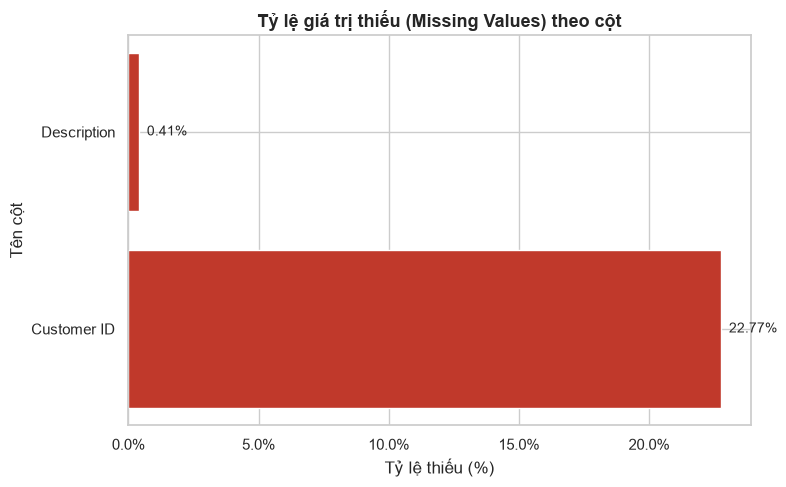

,Missing Count,Missing Percentage (%)
Customer ID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
InvoiceDate,0,0.00
Quantity,0,0.00
Price,0,0.00
Country,0,0.00
Sheet,0,0.00
Invoice_str,0,0.00


In [122]:
missing_summary = plot_missing_values(df, save_as="1. Missing Values.png")

missing_summary_display = missing_summary.rename(columns={
    "missing_count": "Missing Count",
    "missing_pct": "Missing Percentage (%)"
})

missing_summary_display

In [37]:
# Xuất bảng thống kê Missing Values ra Data/Interim/
# Đây là minh chứng cho kết quả phân tích Missing Values
from Source.Utils.IO import save_to_csv

save_to_csv(
    missing_summary.reset_index().rename(columns={
        "index": "Column",
        "missing_count": "Missing Count",
        "missing_pct": "Missing Percentage (%)"
    }),
    INTERIM_DATA_DIR / "Missing_Values_Summary.csv"
)

Đã lưu file: D:\Lilith\Customer-Analytics-for-E-Commerce\Data\Interim\Missing_Values_Summary.csv  (Số dòng: 9 | Số cột: 3)


**Nhận xét:** 
- `Customer ID` bị thiếu ở một tỷ lệ đáng kể, nghĩa là các giao dịch này không thể xác định được khách hàng cụ thể. Các dòng này có thể được giữ lại cho pipeline MBA vì phân tích Market Basket Analysis chủ yếu dựa trên hóa đơn và sản phẩm, không bắt buộc phải xác định khách hàng; ngược lại, cần loại bỏ hoặc xử lý riêng trong pipeline RFM/Churn vì cả hai đều yêu cầu thông tin khách hàng.

- `Description` bị thiếu ở tỷ lệ rất nhỏ. Các dòng này cần được kiểm tra thêm về `StockCode` và các đặc điểm của giao dịch để xác định nguyên nhân.


### 4. Phân tích dòng trùng lặp (Duplicate)

In [43]:
# Các cột dùng để xác định dòng trùng lặp, không tính cột Sheet
duplicate_check_columns = [
    col for col in df.columns
    if col != "Sheet"
]

# Số dòng trùng lặp dư thừa, giữ lại lần xuất hiện đầu tiên của mỗi bản ghi
duplicate_row_count = df.duplicated(
    subset=duplicate_check_columns
).sum()

# Tỷ lệ dòng trùng lặp dư thừa
duplicate_row_pct = duplicate_row_count / len(df) * 100

print(
    f"Số dòng trùng lặp (không tính cột Sheet): "
    f"{duplicate_row_count:,} "
    f"({duplicate_row_pct:.2f}% tổng dữ liệu)"
)

# Xem một số nhóm dòng trùng lặp để kiểm tra bản chất
duplicate_examples = (
    df[
        df.duplicated(
            subset=duplicate_check_columns,
            keep=False
        )
    ]
    .sort_values(duplicate_check_columns)
)

duplicate_examples.head(6)

Số dòng trùng lặp (không tính cột Sheet): 34,335 (3.22% tổng dữ liệu)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,Year 2009-2010
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,Year 2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,Year 2009-2010


**Nhận xét:** 
- Có 34,335 dòng trùng lặp, chiếm 3.22% tổng số dòng dữ liệu khi không tính cột `Sheet`. 

- Các dòng này có giá trị giống nhau trên toàn bộ các cột dữ liệu được sử dụng để kiểm tra trùng lặp. Để tránh ghi nhận cùng một giao dịch nhiều lần, có thể loại bỏ các bản ghi trùng lặp bằng `drop_duplicates()`, giữ lại lần xuất hiện đầu tiên của mỗi nhóm trùng lặp.


### 5. Phân tích Invoice huỷ

Các Invoice có mã bắt đầu bằng chữ **"C"** là hoá đơn hủy (Cancellation) — Đi kèm `Quantity` âm, thể hiện việc trả hàng/huỷ đơn.

In [51]:
# Chuyển Invoice sang kiểu string để kiểm tra tiền tố "C"
invoice_str = df["Invoice"].astype("string")

# Xác định các dòng thuộc Invoice huỷ
is_cancelled_invoice = invoice_str.str.startswith("C", na=False)

# Số dòng thuộc Invoice huỷ
cancelled_row_count = is_cancelled_invoice.sum()

# Số Invoice huỷ duy nhất
cancelled_invoice_count = df.loc[
    is_cancelled_invoice, "Invoice"
].nunique()

# Tổng số Invoice duy nhất
total_invoice_count = df["Invoice"].nunique()

print(
    f"Số dòng thuộc hóa đơn (Invoice) huỷ   : "
    f"{cancelled_row_count:,} "
    f"({cancelled_row_count / len(df) * 100:.2f}% tổng số dòng)"
)

print(
    f"Số hóa đơn huỷ / Tổng hóa đơn            : "
    f"{cancelled_invoice_count:,} / {total_invoice_count:,} "
    f"({cancelled_invoice_count / total_invoice_count * 100:.2f}%)"
)

# Xem một số Invoice huỷ để kiểm tra
cancelled_invoice_examples = df.loc[
    is_cancelled_invoice,
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]
]

cancelled_invoice_examples.head(5)

Số dòng thuộc hóa đơn (Invoice) huỷ   : 19,494 (1.83% tổng số dòng)
Số hóa đơn huỷ / Tổng hóa đơn            : 8,292 / 53,628 (15.46%)


,Invoice,StockCode,Description,Quantity,Price,Customer ID
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95,16321.0
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65,16321.0
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25,16321.0
181,C489449,21896,POTTING SHED TWINE,-6,2.10,16321.0
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95,16321.0


**Nhận xét:** 
- Có **8,292 Invoice huỷ trên tổng số 53,628 Invoice**, chiếm **15.46% số hoá đơn**; đồng thời có **19,494 dòng dữ liệu** thuộc các hóa đơn huỷ, tương ứng **1.83% tổng số dòng**. 

- Các hóa đơn bắt đầu bằng `C` là hóa đơn huỷ. Tập giao dịch mua thành công, các dòng thuộc hóa đơn huỷ sẽ được loại khỏi trước khi thực hiện pipeline MBA và RFM/Churn.

### 6. Phân tích Quantity và Price âm hoặc bằng 0

- Không phải mọi dòng có `Quantity` âm đều là invoice huỷ. 

- Có một nhóm nhỏ các dòng `Quantity` âm nhưng không thuộc Invoice huỷ (Invoice không bắt đầu bằng "C"). Đây là các bút toán điều chỉnh sổ sách nội bộ (ví dụ hàng thất lạc, hư hỏng), thường có `Description` ghi các từ như "Lost", "Damages", "Thrown away", "Found"... và luôn đi kèm `Price = 0` và thiếu `Customer ID`.

In [69]:
# Xác định các dòng có Quantity âm
negative_quantity_mask = df["Quantity"] < 0

# Số dòng Quantity âm
negative_quantity_count = negative_quantity_mask.sum()

print(
    f"Số dòng Quantity âm                                       : "
    f"{negative_quantity_count:,} "
    f"({negative_quantity_count / len(df) * 100:.2f}%)"
)

# Các dòng có Quantity âm
negative_quantity_rows = df.loc[negative_quantity_mask]

# Quantity âm nhưng không thuộc Invoice huỷ
negative_quantity_non_cancelled = negative_quantity_rows.loc[
    ~negative_quantity_rows["Invoice"].astype("string").str.startswith(
        "C", na=False
    )
]

# Số dòng Quantity âm thuộc Invoice huỷ
negative_quantity_cancelled_count = (
    negative_quantity_rows["Invoice"]
    .astype("string")
    .str.startswith("C", na=False)
    .sum()
)

print(
    f"Trong đó, thuộc Invoice huỷ                            : "
    f"{negative_quantity_cancelled_count:,}"
)

print(
    f"Quantity âm nhưng không thuộc Invoice huỷ : "
    f"{len(negative_quantity_non_cancelled):,}"
)

Số dòng Quantity âm                                       : 22,950 (2.15%)
Trong đó, thuộc Invoice huỷ                            : 19,493
Quantity âm nhưng không thuộc Invoice huỷ : 3,457


In [70]:
# Kiểm tra đặc điểm của nhóm Quantity âm không phải Invoice huỷ
print(
    "Đặc điểm nhóm này "
    "(Kiểm tra: Price = 0 và Customer ID bị thiếu):"
)

print(
    f"  -  Tỷ lệ Price = 0                  : "
    f"{(negative_quantity_non_cancelled['Price'] == 0).mean() * 100:.1f}%"
)

print(
    f"  -  Tỷ lệ thiếu Customer ID   : "
    f"{negative_quantity_non_cancelled['Customer ID'].isnull().mean() * 100:.1f}%"
)

negative_quantity_non_cancelled[
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID",]].head(10)

Đặc điểm nhóm này (Kiểm tra: Price = 0 và Customer ID bị thiếu):
  -  Tỷ lệ Price = 0                  : 100.0%
  -  Tỷ lệ thiếu Customer ID   : 100.0%


,Invoice,StockCode,Description,Quantity,Price,Customer ID
263,489464,21733,85123a mixed,-96,0.0,NaN
283,489463,71477,short,-240,0.0,NaN
284,489467,85123A,21733 mixed,-192,0.0,NaN
470,489521,21646,NaN,-50,0.0,NaN
3114,489655,20683,NaN,-44,0.0,NaN
3162,489660,35956,lost,-1043,0.0,NaN
3168,489663,35605A,damages,-117,0.0,NaN
4296,489806,18010,NaN,-770,0.0,NaN
4538,489820,21133,invcd as 84879?,-720,0.0,NaN
4566,489821,85049G,NaN,-240,0.0,NaN


In [80]:
# Rà các Description chứa từ khoá liên quan đến hư hỏng / thất lạc / điều chỉnh sổ sách
import re

adjustment_keywords = ["LOST", "DAMAGE", "DAMAGES", "FOUND", "MISSING", "THROWN AWAY", "WRONG", 
                       "SMASHED", "CRUSHED", "MOULDY", "RUSTY", "CHECK", "ADJUST",]

# Chỉ kiểm tra nhóm Quantity âm nhưng không phải Invoice huỷ
non_cancelled_desc_upper = (
    negative_quantity_non_cancelled["Description"]
    .astype("string")
    .str.upper()
)

# Tạo pattern tìm kiếm, escape để keyword được hiểu đúng như văn bản
adjustment_keyword_pattern = "|".join(
    re.escape(keyword)
    for keyword in adjustment_keywords
)

# Xác định các dòng có ít nhất một keyword
has_adjustment_keyword = non_cancelled_desc_upper.str.contains(
    adjustment_keyword_pattern,
    na=False,
    regex=True,
)

print(
    "Số dòng Quantity âm không phải Invoice huỷ "
    "có Description chứa từ khoá liên quan:"
)

# Thống kê từng keyword
for keyword in adjustment_keywords:
    keyword_count = non_cancelled_desc_upper.str.contains(
        re.escape(keyword),
        na=False,
        regex=True,
    ).sum()

    if keyword_count > 0:
        print(f"  - '{keyword}': {keyword_count:,} dòng")

# Tổng số dòng không trùng lặp
print(
    f"\nTổng cộng (không trùng lặp): "
    f"{has_adjustment_keyword.sum():,} dòng"
)

Số dòng Quantity âm không phải Invoice huỷ có Description chứa từ khoá liên quan:
  - 'LOST': 11 dòng
  - 'DAMAGE': 217 dòng
  - 'DAMAGES': 110 dòng
  - 'FOUND': 1 dòng
  - 'MISSING': 41 dòng
  - 'THROWN AWAY': 22 dòng
  - 'WRONG': 18 dòng
  - 'SMASHED': 10 dòng
  - 'CRUSHED': 9 dòng
  - 'MOULDY': 5 dòng
  - 'RUSTY': 12 dòng
  - 'CHECK': 133 dòng
  - 'ADJUST': 10 dòng

Tổng cộng (không trùng lặp): 481 dòng


In [85]:
# Trường hợp đặc biệt: "Adjust bad debt", Bút toán xoá nợ xấu kế toán. Không phải giao dịch thực tế, cần loại bỏ khỏi phân tích.

# Invoice bắt đầu bằng "A" và StockCode = "B"
invoice_str = df["Invoice"].astype("string")
stock_code_str = df["StockCode"].astype("string").str.strip()

is_bad_debt_adjustment = (
    invoice_str.str.startswith("A", na=False)
    & stock_code_str.eq("B")
)

bad_debt_adjustment_count = is_bad_debt_adjustment.sum()

if bad_debt_adjustment_count > 0:
    print(
        f"Phát hiện {bad_debt_adjustment_count:,} dòng "
        f"Adjust bad debt  (Invoice bắt đầu bằng 'A', "
        f"StockCode = 'B')."
    )

    display_cols = ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID",]

    display(df.loc[is_bad_debt_adjustment, display_cols])

else:
    print("Không phát hiện dòng 'Adjust bad debt'.")

Phát hiện 6 dòng Adjust bad debt  (Invoice bắt đầu bằng 'A', StockCode = 'B').


,Invoice,StockCode,Description,Quantity,Price,Customer ID
179403,A506401,B,Adjust bad debt,1,-53594.36,NaN
276274,A516228,B,Adjust bad debt,1,-44031.79,NaN
403472,A528059,B,Adjust bad debt,1,-38925.87,NaN
825443,A563185,B,Adjust bad debt,1,11062.06,NaN
825444,A563186,B,Adjust bad debt,1,-11062.06,NaN
825445,A563187,B,Adjust bad debt,1,-11062.06,NaN


In [89]:
# Price = 0

price_zero_mask = df["Price"] == 0
price_zero_count = price_zero_mask.sum()

print(
    f"Tổng số dòng Price = 0: "
    f"{price_zero_count:,} "
    f"({price_zero_count / len(df) * 100:.2f}%)"
)

print(
    "(Bao gồm cả các dòng điều chỉnh sổ sách đã phát hiện ở trên "
    "và có thể có thêm các dòng khác.)"
)

Tổng số dòng Price = 0: 6,202 (0.58%)
(Bao gồm cả các dòng điều chỉnh sổ sách đã phát hiện ở trên và có thể có thêm các dòng khác.)


**Nhận xét:** 
- Qua phân tích, dữ liệu có một số nhóm giao dịch đặc biệt cần được xử lý riêng trước khi xây dựng tập giao dịch sạch. Nhóm thứ nhất là các dòng có `Quantity` âm nhưng không thuộc Invoice huỷ; một phần trong nhóm này có `Description` chứa các từ khoá liên quan đến mất mát, hư hỏng hoặc điều chỉnh, cần được kiểm tra và phân loại riêng. Nhóm thứ hai là các dòng `Adjust bad debt`, được nhận diện theo điều kiện `Invoice` bắt đầu bằng `"A"` và `StockCode = "B"`.

- Các nhóm dữ liệu đặc biệt này có thể làm sai lệch các thống kê và chỉ số giao dịch nếu được xử lý như giao dịch bán hàng thông thường, đặc biệt khi tính các chỉ tiêu liên quan đến doanh thu hoặc giá trị giao dịch. Vì vậy, các dòng được xác định là **không thuộc giao dịch bán hàng thực tế** sẽ được loại khỏi bước Cleaning.


### 7. Phân tích StockCode không phải sản phẩm thật

Một số `StockCode` không đại diện cho sản phẩm vật lý mà là các khoản phí/phụ phí/nghiệp vụ kế toán:
`POST` (phí bưu điện), `DOT` (phí), `M`/`Manual` (thủ công), `D` (chiết khấu/Discount),
`BANK CHARGES` (phí ngân hàng), `CRUK` (từ thiện Cancer Research UK), `AMAZONFEE` (phí Amazon),
`S` (mẫu thử/Samples), `C2` (phí vận chuyển/Carriage), `PADS`, `ADJUST` (điều chỉnh), và
`TEST001`/`TEST002` (dữ liệu test nội bộ).

In [95]:
#  Kiểm tra các StockCode không phải sản phẩm vật lý

non_product_stock_codes = ["POST", "DOT", "M", "D", "BANK CHARGES", "CRUK", "AMAZONFEE", 
                           "S", "C2", "PADS", "ADJUST", "TEST001", "TEST002",]

# Chuẩn hóa StockCode một lần để so sánh
stock_code_normalized = (df["StockCode"].astype("string").str.strip().str.upper())

# Tạo bảng kết quả
non_product_summary = []

for stock_code in non_product_stock_codes:
    matching_rows = df.loc[stock_code_normalized == stock_code]

    if not matching_rows.empty:
        common_description = matching_rows["Description"].mode()
        common_description = (common_description.iloc[0]if not common_description.empty else "N/A")

        non_product_summary.append({
            "StockCode": stock_code,
            "Số dòng": len(matching_rows),
            "Ví dụ Description": common_description
        })

# Chuyển thành DataFrame
non_product_summary = pd.DataFrame(non_product_summary)

# Tính tổng
total_non_product_rows = non_product_summary["Số dòng"].sum()

# Thêm dòng tổng cộng
non_product_summary.loc[len(non_product_summary)] = {
    "StockCode": "Tổng cộng",
    "Số dòng": total_non_product_rows,
    "Ví dụ Description": ""
}

# Hiển thị bảng
display(non_product_summary)

# Tỷ lệ trên toàn bộ dữ liệu
print(
    f"Tổng số dòng: {total_non_product_rows:,} "
    f"({total_non_product_rows / len(df) * 100:.2f}% tổng dữ liệu)"
)

,StockCode,Số dòng,Ví dụ Description
0,POST,2122,POSTAGE
1,DOT,1446,DOTCOM POSTAGE
2,M,1426,Manual
3,D,177,Discount
4,BANK CHARGES,102,Bank Charges
5,CRUK,16,CRUK Commission
6,AMAZONFEE,43,AMAZON FEE
7,S,104,SAMPLES
8,C2,282,CARRIAGE
9,PADS,19,PADS TO MATCH ALL CUSHIONS


Tổng số dòng: 5,821 (0.55% tổng dữ liệu)


In [100]:
# Ảnh hưởng của các StockCode không phải sản phẩm đến giá trị giao dịch dương

# Giá trị giao dịch tạm thời
total_price_temp = df["Quantity"] * df["Price"]

# Chuẩn hóa StockCode để so sánh
stock_code_normalized = (df["StockCode"].astype("string").str.strip().str.upper())

# Xác định các dòng thuộc nhóm StockCode không phải sản phẩm
is_non_product_stock = stock_code_normalized.isin (non_product_stock_codes)

# Chỉ xét các dòng có Quantity và Price đều dương
is_positive_transaction = ((df["Quantity"] > 0) & (df["Price"] > 0))

# Giá trị giao dịch dương từ các mã không phải sản phẩm
non_product_value = total_price_temp.loc[is_non_product_stock & is_positive_transaction].sum()

# Tổng giá trị giao dịch dương
total_positive_value = total_price_temp.loc[is_positive_transaction].sum()

print(
    f"Giá trị giao dịch dương từ các mã không phải sản phẩm : "
    f"£ {non_product_value:,.0f}"
)

print(
    f"Giá trị giao dịch dương của toàn bộ dữ liệu                     : "
    f"£ {total_positive_value:,.0f}"
)

print(
    f"Tỷ lệ : "
    f"{non_product_value / total_positive_value * 100:.2f}% "
    f"giá trị giao dịch dương đến từ các mã không phải sản phẩm"
)

Giá trị giao dịch dương từ các mã không phải sản phẩm : £ 849,238
Giá trị giao dịch dương của toàn bộ dữ liệu                     : £ 20,972,968
Tỷ lệ : 4.05% giá trị giao dịch dương đến từ các mã không phải sản phẩm


**Nhận xét:**
- Các `StockCode` không phải sản phẩm chỉ chiếm **0.55% số dòng dữ liệu** (5,821 dòng) nhưng chiếm tới **4.05% tổng giá trị giao dịch dương**.

- Vì vậy, nhóm này cần được loại khỏi tập giao dịch sản phẩm trước khi xây dựng MBA, nhằm tránh tạo ra các luật kết hợp phản ánh phí/phụ phí thay vì hành vi mua sản phẩm.

- Đồng thời, cần loại các dòng này trước khi tính **Monetary** cho RFM để tránh đưa các khoản phí hoặc nghiệp vụ không phải giá trị bán sản phẩm vào giá trị chi tiêu của khách hàng.


### 8. So sánh Outlier: IQR vs Z-score

- `Quantity` có độ lệch (Skewness) rất cao do một số giao dịch bán buôn với số lượng
cực lớn. Ta sẽ chứng minh bằng số liệu cụ thể rằng: Nếu dùng Z-score trực tiếp trên dữ liệu gốc (chưa
Transform), phương pháp này cho kết quả sai lệch (bắt được quá ít Outlier) so với IQR — Vì độ lệch chuẩn
bị vài giá trị cực lớn kéo giãn ra. Cần `log1p`-transform trước khi tính Z-score để có kết quả hợp lý hơn.

- Ta chỉ xét trên các dòng có `Quantity > 0` và `Price > 0` (tức giao dịch mua thành công, đã loại Invoice
huỷ và các dòng bất thường) để phân tích Outlier có ý nghĩa thực tế.

In [102]:
# Kiểm tra độ lệch của Quantity trước và sau log1p

positive_transaction_data = df[(df["Quantity"] > 0) & (df["Price"] > 0)].copy()

original_quantity_skewness = skew(positive_transaction_data["Quantity"])

log_quantity_skewness = skew(np.log1p(positive_transaction_data["Quantity"]))

print(
    f"Skewness của Quantity (Dữ liệu gốc, dương): "
    f"{original_quantity_skewness:.2f}"
)

print(
    f"Skewness của log1p(Quantity): "
    f"{log_quantity_skewness:.2f}"
)

print(
    "(Skewness càng gần 0 thì phân phối càng đối xứng; "
    "giá trị dương lớn cho thấy phân phối lệch phải mạnh.)"
)

Skewness của Quantity (Dữ liệu gốc, dương): 459.99
Skewness của log1p(Quantity): 1.06
(Skewness càng gần 0 thì phân phối càng đối xứng; giá trị dương lớn cho thấy phân phối lệch phải mạnh.)


In [106]:
# So sánh Outlier: IQR vs Z-score

# Phương pháp 1: IQR 
quantity_q1, quantity_q3 = positive_transaction_data["Quantity"].quantile([0.25, 0.75])

quantity_iqr = quantity_q3 - quantity_q1

quantity_lower_bound = quantity_q1 - 1.5 * quantity_iqr
quantity_upper_bound = quantity_q3 + 1.5 * quantity_iqr

is_outlier_iqr = (
    (positive_transaction_data["Quantity"] < quantity_lower_bound)
    | (positive_transaction_data["Quantity"] > quantity_upper_bound)
)

iqr_outlier_count = is_outlier_iqr.sum()
iqr_outlier_pct = (
    iqr_outlier_count / len(positive_transaction_data) * 100
)

print(
    f"[IQR] Q1 = {quantity_q1:.1f}, "
    f"Q3 = {quantity_q3:.1f}, "
    f"IQR = {quantity_iqr:.1f}, "
    f"cận = ({quantity_lower_bound:.1f}, {quantity_upper_bound:.1f})"
)

print(
    f"[IQR] Số outlier phát hiện: "
    f"{iqr_outlier_count:,} "
    f"({iqr_outlier_pct:.2f}%)"
)


# Phương pháp 2: Z-score trên dữ liệu gốc
quantity_mean = positive_transaction_data["Quantity"].mean()
quantity_std = positive_transaction_data["Quantity"].std()

quantity_zscore = (positive_transaction_data["Quantity"] - quantity_mean) / quantity_std

is_outlier_zscore_original = quantity_zscore.abs() > 3

zscore_original_count = is_outlier_zscore_original.sum()
zscore_original_pct = (zscore_original_count / len(positive_transaction_data) * 100)

print(
    f"\n[Z - Score, dữ liệu gốc] Số Outlier phát hiện: "
    f"{zscore_original_count:,} "
    f"({zscore_original_pct:.2f}%)"
)


# Phương pháp 3: Z-score sau log1p-transform
log_quantity = np.log1p(positive_transaction_data["Quantity"])

log_quantity_mean = log_quantity.mean()
log_quantity_std = log_quantity.std()

log_quantity_zscore = (
    log_quantity - log_quantity_mean
) / log_quantity_std

is_outlier_zscore_log = log_quantity_zscore.abs() > 3

zscore_log_count = is_outlier_zscore_log.sum()
zscore_log_pct = (zscore_log_count / len(positive_transaction_data) * 100)

print(
    f"[Z - Score, sau log1p] Số Outlier phát hiện: "
    f"{zscore_log_count:,} "
    f"({zscore_log_pct:.2f}%)"
)

[IQR] Q1 = 1.0, Q3 = 10.0, IQR = 9.0, cận = (-12.5, 23.5)
[IQR] Số outlier phát hiện: 111,341 (10.69%)

[Z - Score, dữ liệu gốc] Số Outlier phát hiện: 1,590 (0.15%)
[Z - Score, sau log1p] Số Outlier phát hiện: 9,939 (0.95%)


In [109]:
# Bảng so sánh kết quả phát hiện Outlier
outlier_comparison = pd.DataFrame({
    "Phương pháp": ["IQR", "Z - Score (Dữ liệu gốc)", "Z - Score (Sau log1p)",],
    "Số Outlier": [iqr_outlier_count, zscore_original_count, zscore_log_count,],
    "Tỷ lệ (%)": [iqr_outlier_pct, zscore_original_pct, zscore_log_pct,],
})

outlier_comparison

,Phương pháp,Số Outlier,Tỷ lệ (%)
0,IQR,111341,10.688692
1,Z - Score (Dữ liệu gốc),1590,0.152639
2,Z - Score (Sau log1p),9939,0.954140


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\2. Quantity Histogram Box.png


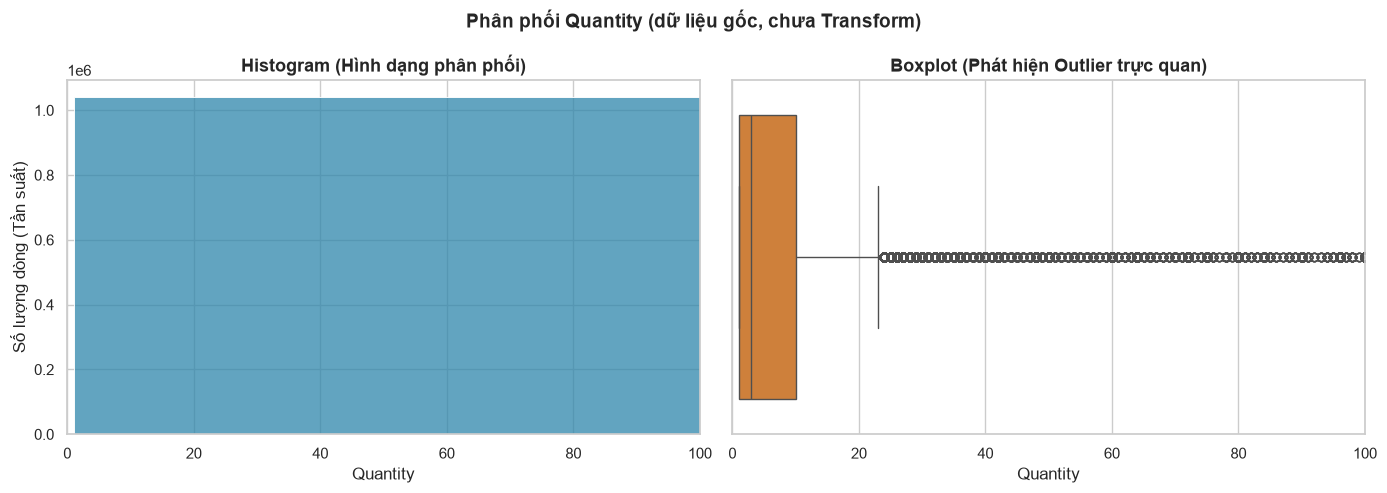

In [121]:
# Phân phối Quantity - Dữ liệu gốc
plot_histogram_boxplot(
    positive_transaction_data,
    "Quantity",
    title="Phân phối Quantity (dữ liệu gốc, chưa Transform)",
    xlim=(0, positive_transaction_data["Quantity"].quantile(0.99)),
    save_as="2. Quantity Histogram Box.png"
)

**Nhận xét:** 
- Kết quả cho thấy Z - Score trên dữ liệu `Quantity` gốc phát hiện **1,590 Outliers (0.15%)**, thấp hơn rất nhiều so với **111,341 Outliers (10.69%)** được phát hiện bằng IQR. 

- Điều này phù hợp với đặc điểm `Quantity` có phân phối lệch phải rất mạnh (`Skewness = 459.99`), khiến phương pháp Z - Score trên dữ liệu gốc kém nhạy hơn với các giá trị lớn. 

- Sau khi áp dụng `log1p`, số Outliers theo Z - Score tăng lên **9,939 dòng (0.95%)**, cao hơn đáng kể so với dữ liệu gốc và gần IQR hơn về mức độ phát hiện, mặc dù vẫn có sự khác biệt lớn. 

- **Kết luận: Nếu sử dụng Z-Score để phát hiện Outliers cho `Quantity`, nên thực hiện `log1p`-Transform trước; đây là căn cứ kỹ thuật cho bước xử lý Outliers trong `Cleaning.py`.**


## 9. Outlier Quantity cao — bán buôn hợp lệ hay lỗi nhập liệu?

Giả thuyết: Nếu nhóm Quantity cao có `Price` trung vị thấp hơn Price trung vị chung, đây là dấu hiệu
ủng hộ giả thuyết "bán buôn hợp lệ, giá ưu đãi cho số lượng lớn".

In [114]:
# Kiểm tra nhóm Quantity cao

# Ngưỡng Quantity thuộc top 1%
high_quantity_threshold = positive_transaction_data["Quantity"].quantile(0.99)

# Nhóm có Quantity nằm trong top 1%
high_quantity_group = positive_transaction_data[positive_transaction_data["Quantity"] >= high_quantity_threshold]

# Median Price của toàn bộ dữ liệu giao dịch dương
overall_median_price = positive_transaction_data["Price"].median()

# Median Price của nhóm Quantity cao
high_quantity_median_price = high_quantity_group["Price"].median()

print(
    f"Ngưỡng Quantity cao (Percentile 99): "
    f"{high_quantity_threshold:.0f}"
)

print(
    f"Số dòng thuộc nhóm Quantity cao     : "
    f"{len(high_quantity_group):,}"
)

print(
    f"\nPrice trung vị của nhóm Quantity cao: "
    f"£{high_quantity_median_price:.2f}"
)

print(
    f"Price trung vị của toàn bộ dữ liệu  : "
    f"£{overall_median_price:.2f}"
)

# 5 giao dịch có Quantity cao nhất
high_quantity_group.nlargest(
    5, "Quantity")[ 
                   ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Country",] 
                   ]

Ngưỡng Quantity cao (Percentile 99): 100
Số dòng thuộc nhóm Quantity cao     : 13,524

Price trung vị của nhóm Quantity cao: £1.06
Price trung vị của toàn bộ dữ liệu  : £2.10


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902.0,Denmark
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902.0,Denmark
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902.0,Denmark


**Nhận xét:** 
- `Price` trung vị của nhóm `Quantity` cao là **£1.06**, thấp hơn đáng kể so với **£2.10** của toàn bộ dữ liệu giao dịch dương.

- Kết quả này **ủng hộ giả thuyết** rằng một phần các đơn hàng có `Quantity` lớn có thể là các giao dịch số lượng lớn với giá đơn vị thấp hơn, thay vì hoàn toàn do lỗi nhập liệu. Vì vậy, **không tự động xoá toàn bộ các dòng có Quantity cao** khi xử lý outlier; các ngưỡng Outliers nên được sử dụng để nhận diện và kiểm tra các trường hợp bất thường, kết hợp với `StockCode`, `Description`, khách hàng và ngữ cảnh giao dịch trước khi quyết định loại bỏ.

### 10. Phân tích Country

In [116]:
# Phân bố giao dịch theo Country

country_distribution = df["Country"].value_counts()

uk_transaction_pct = (country_distribution.get("United Kingdom", 0) / len(df) * 100)

print(
    f"Số quốc gia khác nhau: "
    f"{df['Country'].nunique()}"
)

print(
    f"Tỷ lệ United Kingdom: "
    f"{uk_transaction_pct:.2f}%"
)

print("\nTop 10 quốc gia có nhiều dòng dữ liệu nhất:")

country_distribution.head(10)

Số quốc gia khác nhau: 43
Tỷ lệ United Kingdom: 91.94%

Top 10 quốc gia có nhiều dòng dữ liệu nhất:


Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

In [118]:
# Mối liên hệ giữa Country và tỷ lệ thiếu Customer ID

customer_id_missing_by_country = (
    df.groupby("Country")["Customer ID"]
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
)

print("Top 10 quốc gia có tỷ lệ thiếu Customer ID cao nhất: ")

print(customer_id_missing_by_country.head(10))

print(
    f"\nRiêng United Kingdom: "
    f"{customer_id_missing_by_country.get('United Kingdom', float('nan')):.2f}% "
    f"thiếu Customer ID"
)

Top 10 quốc gia có tỷ lệ thiếu Customer ID cao nhất: 
Country
Bermuda                 100.000000
Hong Kong               100.000000
Bahrain                  53.174603
Unspecified              30.687831
RSA                      27.218935
United Kingdom           24.459560
United Arab Emirates     22.800000
Lebanon                  22.413793
Israel                   12.668464
EIRE                      9.352961
Name: Customer ID, dtype: float64

Riêng United Kingdom: 24.46% thiếu Customer ID


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\3. Top 10 Country.png


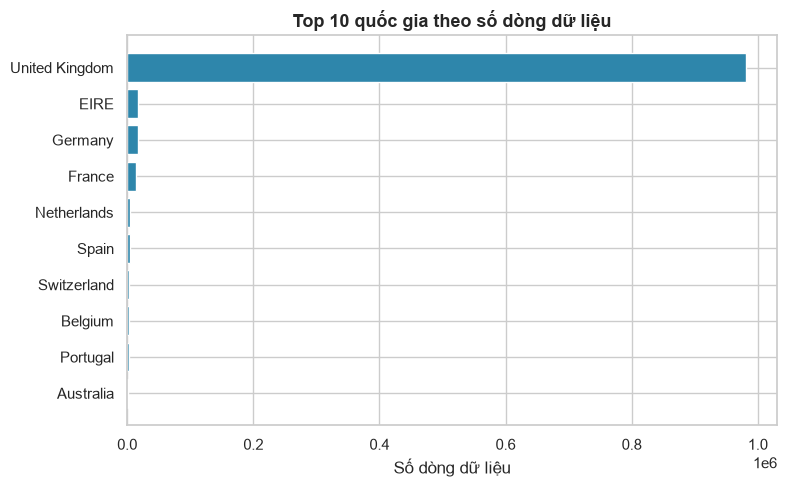

In [120]:
# Biểu đồ Top 10 quốc gia theo số dòng dữ liệu

fig, ax = plt.subplots(figsize=(8, 5))

top10_countries = country_distribution.head(10)

ax.barh(
    top10_countries.index[::-1],
    top10_countries.values[::-1],
    color=PRIMARY_COLOR
)

ax.set_title("Top 10 quốc gia theo số dòng dữ liệu")
ax.set_xlabel("Số dòng dữ liệu")

plt.tight_layout()

save_current_figure("3. Top 10 Country.png")

plt.show()

**Nhận xét:** 
- Dữ liệu tập trung áp đảo tại **United Kingdom**, với **981,330 dòng, chiếm 91.94%** tổng số dòng dữ liệu, cao hơn rất nhiều so với các quốc gia còn lại. 

- Do đó, các kết quả phân tích MBA/RFM/Churn trên toàn bộ dữ liệu có khả năng phản ánh chủ yếu đặc điểm của khách hàng tại UK. Khi phân tích riêng theo quốc gia, cần xem xét quy mô dữ liệu của từng quốc gia để tránh đưa ra kết luận thiếu ổn định đối với các nhóm có số quan sát nhỏ.